In [1]:
import time
import os
import copy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
import torch.nn.functional as F

import torchquantum as tq
import numpy as np

import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import (roc_auc_score, confusion_matrix,
                             classification_report, roc_curve, auc)
from sklearn.preprocessing import label_binarize
import seaborn as sns

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

os.environ["OMP_NUM_THREADS"] = "1"

print(f"TorchQuantum version: {tq.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")


TorchQuantum version: 0.1.8
PyTorch version: 2.5.1+cu121
CUDA available: True


In [2]:
# Quantum circuit parameters
n_qubits = 8          # 8 qubits for better feature encoding
q_depth = 6           # 6 layers - balanced depth

# Training parameters - BALANCED learning rates
step = 0.001          # standard learning rate
resnet_lr_factor = 0.1
batch_size = 64
weight_decay = 1e-4
num_epochs = 80
patience = 15

# Model parameters
img_size = 150
in_channels = 1
num_classes = 3

# Classical pre-processing
HIDDEN_DIM = 128
DROPOUT_RATE = 0.3

# Fine-tuning layers
UNFREEZE_LAYERS = ['layer1','layer2','layer3', 'layer4']

# Warmup epochs
WARMUP_EPOCHS = 5

# Data paths - UPDATE THESE
train_dir = "/home/jovyan/work/dataset/dataset/train"
val_dir = "/home/jovyan/work/dataset/dataset/val"

start_time = time.time()

print(f"Quantum circuit: {n_qubits} qubits, {q_depth} layers")
print(f"Fine-tuning layers: {UNFREEZE_LAYERS}")
print(f"Learning rate: {step}")

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Quantum circuit: 8 qubits, 6 layers
Fine-tuning layers: ['layer1', 'layer2', 'layer3', 'layer4']
Learning rate: 0.001
Using device: cuda:0


In [3]:
class NPYImageFolder(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []
        self.classes = sorted([d for d in os.listdir(root_dir)
                               if os.path.isdir(os.path.join(root_dir, d))])
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}

        for class_name in self.classes:
            class_dir = os.path.join(root_dir, class_name)
            for filename in os.listdir(class_dir):
                if filename.endswith('.npy'):
                    filepath = os.path.join(class_dir, filename)
                    self.samples.append((filepath, self.class_to_idx[class_name]))

        print(f"Found {len(self.samples)} samples in {root_dir}")
        print(f"Classes: {self.classes}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        filepath, label = self.samples[idx]
        arr = np.load(filepath)

        if arr.ndim == 2:
            arr = arr[np.newaxis, :, :]
        elif arr.ndim == 3 and arr.shape[0] not in [1, 3]:
            arr = arr.transpose(2, 0, 1)

        if arr.max() > 1.0:
            arr = arr / 255.0

        tensor = torch.tensor(arr, dtype=torch.float32)

        if self.transform:
            tensor = self.transform(tensor)

        return tensor, label


In [4]:
class NPYTransform:
    def __init__(self, img_size, augment=False):
        self.img_size = img_size
        self.augment = augment

    def __call__(self, x):
        # Resize if needed
        if x.shape[-1] != self.img_size or x.shape[-2] != self.img_size:
            x = F.interpolate(x.unsqueeze(0), size=(self.img_size, self.img_size),
                              mode='bilinear', align_corners=False).squeeze(0)

        if self.augment:
            # Horizontal flip
            if torch.rand(1) > 0.5:
                x = torch.flip(x, dims=[-1])

            # Vertical flip
            if torch.rand(1) > 0.5:
                x = torch.flip(x, dims=[-2])

            # 90-degree rotations
            k = torch.randint(0, 4, (1,)).item()
            if k > 0:
                x = torch.rot90(x, k, dims=[-2, -1])

            # Small Gaussian noise
            if torch.rand(1) > 0.7:
                noise_std = torch.rand(1).item() * 0.03
                noise = torch.randn_like(x) * noise_std
                x = torch.clamp(x + noise, 0, 1)

            # Slight brightness variation
            if torch.rand(1) > 0.7:
                bf = 0.9 + torch.rand(1).item() * 0.2
                x = torch.clamp(x * bf, 0, 1)

        # Normalize to [-1, 1]
        x = (x - 0.5) / 0.5
        return x


In [5]:
def get_dataloaders(train_dir, val_dir, img_size, batch_size, test_split=0.10):
    train_transform = NPYTransform(img_size, augment=True)
    val_transform = NPYTransform(img_size, augment=False)

    train_dataset = NPYImageFolder(train_dir, train_transform)
    val_full_dataset = NPYImageFolder(val_dir, val_transform)

    total_val = len(val_full_dataset)
    test_size = int(total_val * test_split)
    val_size = total_val - test_size

    val_dataset, test_dataset = random_split(
        val_full_dataset, [val_size, test_size],
        generator=torch.Generator().manual_seed(42)
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                              num_workers=0, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                            num_workers=0, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                             num_workers=0, pin_memory=True)

    return train_loader, val_loader, test_loader, train_dataset.classes

train_loader, val_loader, test_loader, class_names = get_dataloaders(
    train_dir, val_dir, img_size, batch_size, test_split=0.10
)

dataset_sizes = {
    "train": len(train_loader.dataset),
    "validation": len(val_loader.dataset)
}
dataloaders = {"train": train_loader, "validation": val_loader}

print(f"Dataset sizes: {dataset_sizes}")
print(f"Classes: {class_names}")
print(f"Test set size: {len(test_loader.dataset)}")


Found 30000 samples in /home/jovyan/work/dataset/dataset/train
Classes: ['no', 'sphere', 'vort']
Found 7500 samples in /home/jovyan/work/dataset/dataset/val
Classes: ['no', 'sphere', 'vort']
Dataset sizes: {'train': 30000, 'validation': 6750}
Classes: ['no', 'sphere', 'vort']
Test set size: 750


Batch shape: torch.Size([64, 1, 150, 150])


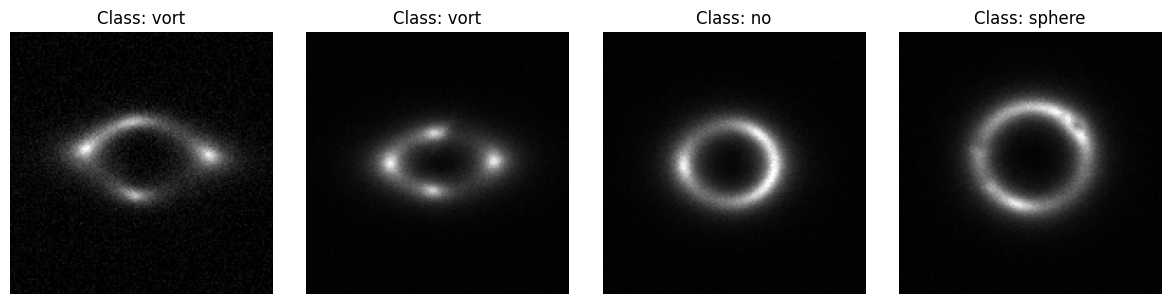

In [6]:
inputs, classes_batch = next(iter(dataloaders["train"]))
print(f"Batch shape: {inputs.shape}")

fig, axes = plt.subplots(1, min(4, len(inputs)), figsize=(12, 3))
for i in range(min(4, len(inputs))):
    ax = axes[i] if len(inputs) > 1 else axes
    img = inputs[i].squeeze().numpy() * 0.5 + 0.5
    ax.imshow(img, cmap='gray')
    ax.set_title(f'Class: {class_names[classes_batch[i]]}')
    ax.axis('off')
plt.tight_layout()
plt.show()


In [7]:
class QuantumCircuit(tq.QuantumModule):
    """
    Enhanced Quantum Circuit for gravitational lensing classification.
    - 8 qubits for finer feature encoding
    - RY + RZ + RX rotations (all three axes)
    - Asymmetric entanglement pattern (helps distinguish sphere vs vort)
    """
    def __init__(self, n_qubits, q_depth):
        super().__init__()
        self.n_qubits = n_qubits
        self.q_depth = q_depth

        # RY variational layers
        self.ry_layers = nn.ModuleList([
            tq.Op1QAllLayer(op=tq.RY, n_wires=n_qubits, has_params=True, trainable=True)
            for _ in range(q_depth)
        ])

        # RZ variational layers
        self.rz_layers = nn.ModuleList([
            tq.Op1QAllLayer(op=tq.RZ, n_wires=n_qubits, has_params=True, trainable=True)
            for _ in range(q_depth)
        ])

        # RX variational layers
        self.rx_layers = nn.ModuleList([
            tq.Op1QAllLayer(op=tq.RX, n_wires=n_qubits, has_params=True, trainable=True)
            for _ in range(q_depth)
        ])

        # Per-qubit Z measurement
        self.measure = tq.MeasureAll(tq.PauliZ)

    def forward(self, q_input_features):
        batch_size = q_input_features.shape[0]

        qdev = tq.QuantumDevice(
            n_wires=self.n_qubits,
            bsz=batch_size,
            device=q_input_features.device
        )

        # Hadamard layer for superposition
        for i in range(self.n_qubits):
            qdev.h(wires=i)

        # Data encoding via RY gates
        for i in range(self.n_qubits):
            qdev.ry(wires=i, params=q_input_features[:, i])

        # Variational layers
        for k in range(self.q_depth):
            # Forward CNOT chain
            for i in range(self.n_qubits - 1):
                qdev.cnot(wires=[i, i + 1])

            # RY rotation
            self.ry_layers[k](qdev)

            # Reverse CNOT chain (asymmetric pattern)
            for i in range(self.n_qubits - 1, 0, -1):
                qdev.cnot(wires=[i, i - 1])

            # RZ rotation
            self.rz_layers[k](qdev)

            # Skip connections (long-range entanglement)
            for i in range(0, self.n_qubits - 2, 2):
                qdev.cnot(wires=[i, i + 2])

            # RX rotation
            self.rx_layers[k](qdev)

            # Circular connection
            qdev.cnot(wires=[self.n_qubits - 1, 0])

        return self.measure(qdev)

print(f"Quantum circuit: {n_qubits} qubits, {q_depth} layers")
print("Using RY+RZ+RX rotations with asymmetric entanglement")


Quantum circuit: 8 qubits, 6 layers
Using RY+RZ+RX rotations with asymmetric entanglement


In [8]:
class DressedQuantumNet(nn.Module):
    def __init__(self, input_features=512, dropout_rate=DROPOUT_RATE):
        super().__init__()

        # Classical pre-processing: 512 -> 256 -> 128 -> 64 -> 32 -> 8 (gradual reduction)
        self.pre_net = nn.Sequential(
            nn.Linear(input_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate * 0.8),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate * 0.6),
            
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout_rate * 0.4),
            
            nn.Linear(32, n_qubits),
        )

        self.quantum_circuit = QuantumCircuit(n_qubits, q_depth)

        # Post-processing: n_qubits -> num_classes
        self.post_net = nn.Sequential(
            nn.Linear(n_qubits, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, num_classes)
        )

    def forward(self, input_features):
        pre_out = self.pre_net(input_features)
        q_in = torch.tanh(pre_out) * np.pi / 2.0
        q_out = self.quantum_circuit(q_in)
        return self.post_net(q_out)

In [9]:
class GrayscaleToRGB(nn.Module):
    def forward(self, x):
        return x.repeat(1, 3, 1, 1)

class ResizeToResNet(nn.Module):
    def forward(self, x):
        return F.interpolate(x, size=(224, 224), mode='bilinear', align_corners=False)

class HybridModel(nn.Module):
    def __init__(self, unfreeze_layers=None):
        super().__init__()
        if unfreeze_layers is None:
            unfreeze_layers = ['layer4']

        self.grayscale_to_rgb = GrayscaleToRGB()
        self.resize = ResizeToResNet()

        # Load pretrained ResNet18
        weights = torchvision.models.ResNet18_Weights.IMAGENET1K_V1
        resnet = torchvision.models.resnet18(weights=weights)

        # Freeze all parameters first
        for param in resnet.parameters():
            param.requires_grad = False

        # Selectively unfreeze specified layers
        layer_mapping = {
            'layer1': resnet.layer1,
            'layer2': resnet.layer2,
            'layer3': resnet.layer3,
            'layer4': resnet.layer4,
        }

        self.unfrozen_layer_names = []
        for layer_name in unfreeze_layers:
            if layer_name in layer_mapping:
                for param in layer_mapping[layer_name].parameters():
                    param.requires_grad = True
                self.unfrozen_layer_names.append(layer_name)
                print(f"  Unfrozen: {layer_name}")

        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        self.layer3 = resnet.layer3
        self.layer4 = resnet.layer4

        self.features = nn.Sequential(*list(resnet.children())[:-1])
        self.flatten = nn.Flatten()
        self.quantum_fc = DressedQuantumNet(input_features=512,dropout_rate=DROPOUT_RATE)

    def forward(self, x):
        x = self.grayscale_to_rgb(x)
        x = self.resize(x)
        x = self.features(x)
        x = self.flatten(x)
        x = self.quantum_fc(x)
        return x

    def get_parameter_groups(self, base_lr, resnet_lr_factor=0.1):
        param_groups = []

        lr_scale = {
            'layer1': resnet_lr_factor * 0.1,
            'layer2': resnet_lr_factor * 0.1,
            'layer3': resnet_lr_factor * 0.5,
            'layer4': resnet_lr_factor,
        }
        layer_map = {
            'layer1': self.layer1,
            'layer2': self.layer2,
            'layer3': self.layer3,
            'layer4': self.layer4,
        }

        for name in self.unfrozen_layer_names:
            param_groups.append({
                'params': layer_map[name].parameters(),
                'lr': base_lr * lr_scale[name],
                'name': name
            })

        param_groups.append({
            'params': self.quantum_fc.parameters(),
            'lr': base_lr,
            'name': 'quantum_fc'
        })

        return param_groups


In [10]:
print(f"Creating HybridModel with fine-tuning...")
model_hybrid = HybridModel(unfreeze_layers=UNFREEZE_LAYERS).to(device)

# Count parameters
total_params = sum(p.numel() for p in model_hybrid.parameters())
trainable_params = sum(p.numel() for p in model_hybrid.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params

print(f"Parameter Summary:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Frozen parameters: {frozen_params:,}")
print(f"  Trainable ratio: {trainable_params/total_params*100:.1f}%")

# Standard CrossEntropyLoss
class_weights = torch.tensor([1.0, 2.5, 2.0], dtype=torch.float32).to(device)  # Adjust weights as needed
criterion = nn.CrossEntropyLoss(weight=class_weights)
print(f"Class weights: {dict(zip(class_names, class_weights.tolist()))}")


# Get parameter groups with different learning rates
param_groups = model_hybrid.get_parameter_groups(step, resnet_lr_factor)

print(f"Optimizer Learning Rates:")
for pg in param_groups:
    print(f"  {pg['name']}: lr={pg['lr']:.6f}")

optimizer_hybrid = optim.Adam(param_groups, weight_decay=weight_decay)

# Cosine annealing with warmup
def warmup_cosine_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(1, num_epochs - WARMUP_EPOCHS)
    return 0.5 * (1.0 + np.cos(np.pi * progress))

exp_lr_scheduler = lr_scheduler.LambdaLR(optimizer_hybrid, lr_lambda=warmup_cosine_lambda)


Creating HybridModel with fine-tuning...
  Unfrozen: layer1
  Unfrozen: layer2
  Unfrozen: layer3
  Unfrozen: layer4
Parameter Summary:
  Total parameters: 11,353,307
  Trainable parameters: 11,343,771
  Frozen parameters: 9,536
  Trainable ratio: 99.9%
Class weights: {'no': 1.0, 'sphere': 2.5, 'vort': 2.0}
Optimizer Learning Rates:
  layer1: lr=0.000010
  layer2: lr=0.000010
  layer3: lr=0.000050
  layer4: lr=0.000100
  quantum_fc: lr=0.001000


In [11]:
def train_model(model, criterion, optimizer, scheduler, num_epochs, patience=15):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    best_loss = float('inf')
    epochs_no_improve = 0

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    print("Training started:")
    print(f"  Early stopping patience: {patience} epochs")
    print(f"  Warmup epochs: {WARMUP_EPOCHS}")

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        print("-" * 35)

        for phase in ["train", "validation"]:
            if phase == "train":
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            pbar = tqdm(dataloaders[phase], desc=f"{phase}")
            for inputs, labels in pbar:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == "train":
                        loss.backward()
                        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                pbar.set_postfix({'loss': f'{loss.item():.4f}'})

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            if phase == "train":
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
                scheduler.step()
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())

                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
                    epochs_no_improve = 0
                    print(f"  New best model! (val_acc={best_acc:.4f})")
                else:
                    epochs_no_improve += 1

                if epoch_loss < best_loss:
                    best_loss = epoch_loss

        if epochs_no_improve >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs")
            break

    time_elapsed = time.time() - since
    print(f"Training completed in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
    print(f"Best val Acc: {best_acc:.4f}")

    model.load_state_dict(best_model_wts)
    return model, history


In [ ]:
model_hybrid, history = train_model(
    model_hybrid, criterion, optimizer_hybrid, exp_lr_scheduler,
    num_epochs=num_epochs, patience=patience
)


Training started:
  Early stopping patience: 15 epochs
  Warmup epochs: 5
Epoch 1/80
-----------------------------------


train: 100%|██████████| 469/469 [01:34<00:00,  4.95it/s, loss=1.0151]


train Loss: 1.0766 Acc: 0.3323


validation: 100%|██████████| 106/106 [00:16<00:00,  6.25it/s, loss=1.0549]


validation Loss: 1.0385 Acc: 0.3327
  New best model! (val_acc=0.3327)
Epoch 2/80
-----------------------------------


...

train: 100%|██████████| 469/469 [01:33<00:00,  5.01it/s, loss=0.0530]


train Loss: 0.1766 Acc: 0.9357


validation: 100%|██████████| 106/106 [00:13<00:00,  8.05it/s, loss=0.3130]


validation Loss: 0.2469 Acc: 0.9249
Epoch 80/80
-----------------------------------


train:  56%|█████▋    | 264/469 [00:57<01:46,  1.93it/s, loss=0.1544]

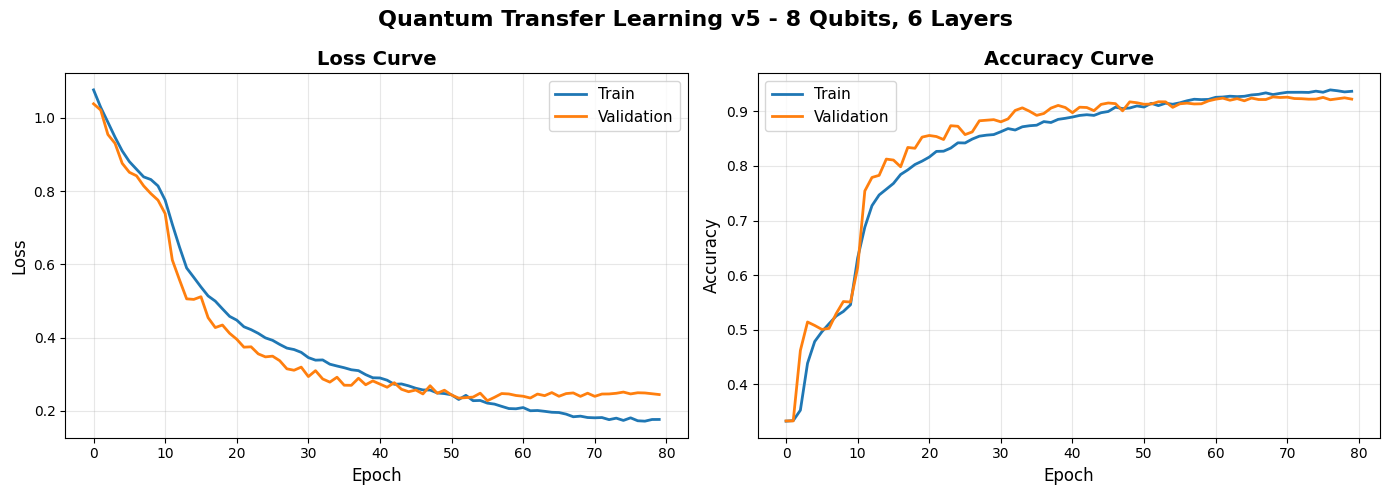

Best Validation Accuracy: 92.65%


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train', linewidth=2)
axes[0].plot(history['val_loss'], label='Validation', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Loss Curve', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_acc'], label='Train', linewidth=2)
axes[1].plot(history['val_acc'], label='Validation', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Accuracy Curve', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Quantum Transfer Learning v5 - {n_qubits} Qubits, {q_depth} Layers',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Best Validation Accuracy: {max(history['val_acc'])*100:.2f}%")


In [21]:
@torch.no_grad()
def evaluate_model(model, test_loader):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    for inputs, labels in tqdm(test_loader, desc="Testing"):
        inputs = inputs.to(device)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    try:
        roc_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
    except Exception:
        roc_auc = 0.0

    return accuracy, all_preds, all_labels, all_probs, roc_auc

test_acc, test_preds, test_labels, test_probs, test_roc_auc = evaluate_model(
    model_hybrid, test_loader
)
print(f"Test Accuracy: {test_acc * 100:.2f}%")
print(f"Test ROC-AUC:  {test_roc_auc:.4f}")


Testing: 100%|██████████| 12/12 [00:01<00:00,  7.83it/s]

Test Accuracy: 92.40%
Test ROC-AUC:  0.9837


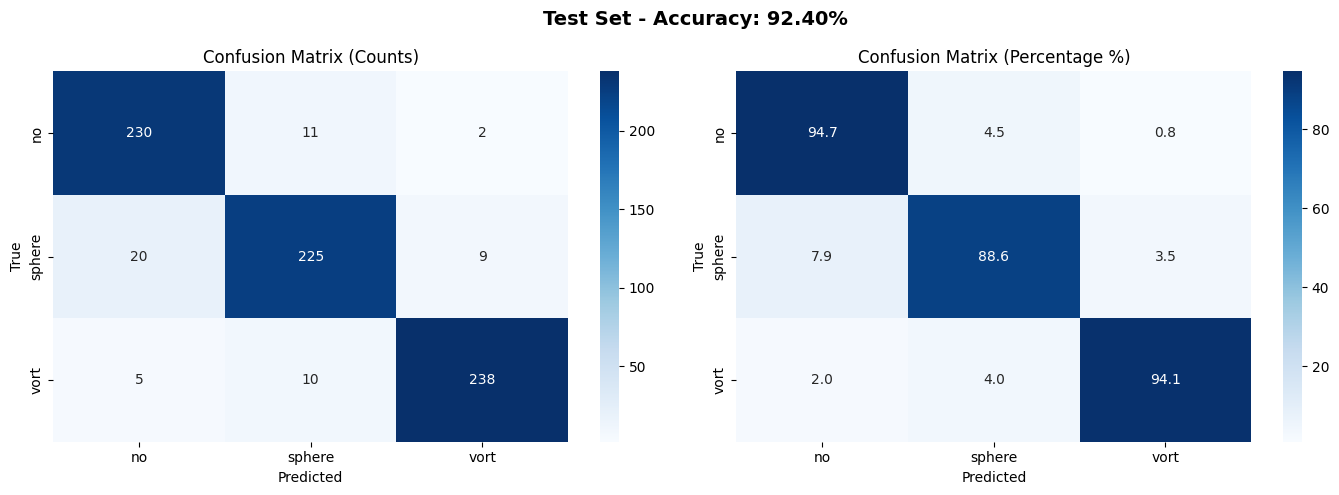

Classification Report:
              precision    recall  f1-score   support

          no     0.9020    0.9465    0.9237       243
      sphere     0.9146    0.8858    0.9000       254
        vort     0.9558    0.9407    0.9482       253

    accuracy                         0.9240       750
   macro avg     0.9241    0.9243    0.9240       750
weighted avg     0.9244    0.9240    0.9239       750



In [22]:
cm = confusion_matrix(test_labels, test_preds)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_title('Confusion Matrix (Counts)')

sns.heatmap(cm_normalized, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
axes[1].set_title('Confusion Matrix (Percentage %)')

plt.suptitle(f'Test Set - Accuracy: {test_acc*100:.2f}%', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Classification Report:")
print("="*60)
print(classification_report(test_labels, test_preds,
                            target_names=class_names, digits=4))


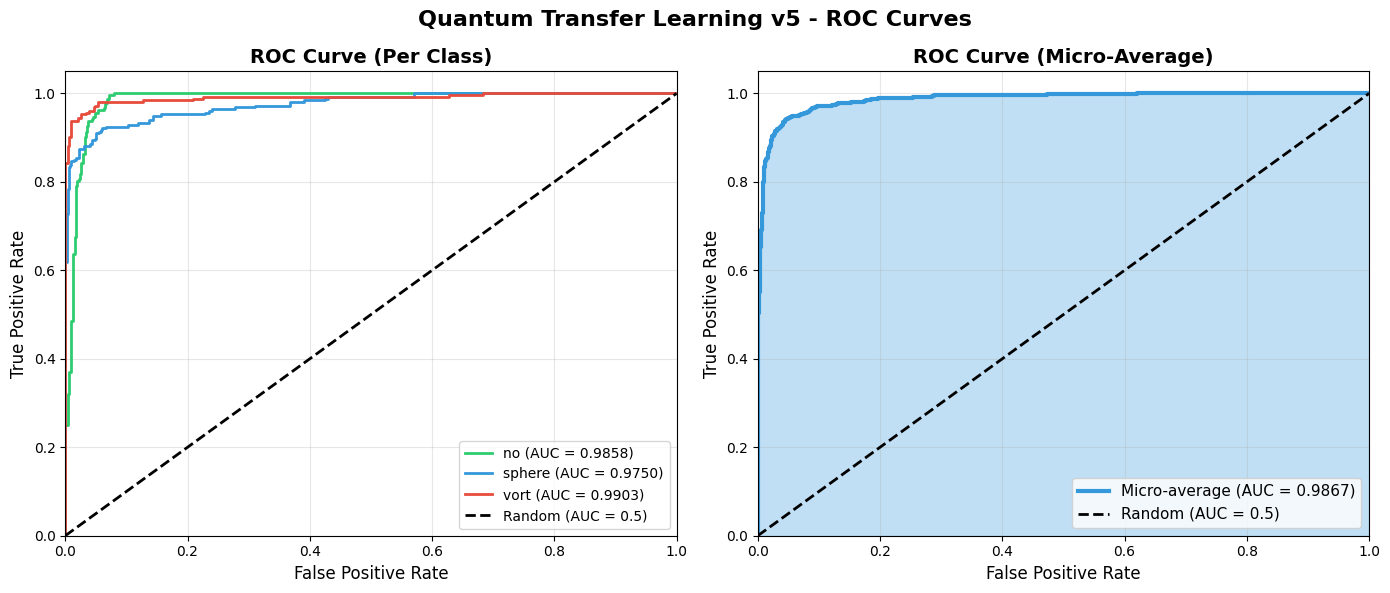

ROC-AUC Summary:
  no: AUC = 0.9858
  sphere: AUC = 0.9750
  vort: AUC = 0.9903
  Micro-average: AUC = 0.9867


In [23]:
n_classes_eval = len(class_names)
y_true_bin = label_binarize(test_labels, classes=list(range(n_classes_eval)))
y_scores = np.array(test_probs)

fpr, tpr, roc_auc_dict = {}, {}, {}
for i in range(n_classes_eval):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
    roc_auc_dict[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_scores.ravel())
roc_auc_dict["micro"] = auc(fpr["micro"], tpr["micro"])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = ['#2ecc71', '#3498db', '#e74c3c']

for i, (cls, color) in enumerate(zip(class_names, colors)):
    axes[0].plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f'{cls} (AUC = {roc_auc_dict[i]:.4f})')

axes[0].plot([0, 1], [0, 1], 'k--', lw=2, label='Random (AUC = 0.5)')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curve (Per Class)', fontsize=14, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(alpha=0.3)

axes[1].fill_between(fpr["micro"], tpr["micro"], alpha=0.3, color='#3498db')
axes[1].plot(fpr["micro"], tpr["micro"], color='#3498db', lw=3,
             label=f'Micro-average (AUC = {roc_auc_dict["micro"]:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=2, label='Random (AUC = 0.5)')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('ROC Curve (Micro-Average)', fontsize=14, fontweight='bold')
axes[1].legend(loc='lower right', fontsize=11)
axes[1].grid(alpha=0.3)

plt.suptitle('Quantum Transfer Learning v5 - ROC Curves', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("ROC-AUC Summary:")
print("="*50)
for i, cls in enumerate(class_names):
    print(f"  {cls}: AUC = {roc_auc_dict[i]:.4f}")
print(f"  Micro-average: AUC = {roc_auc_dict['micro']:.4f}")


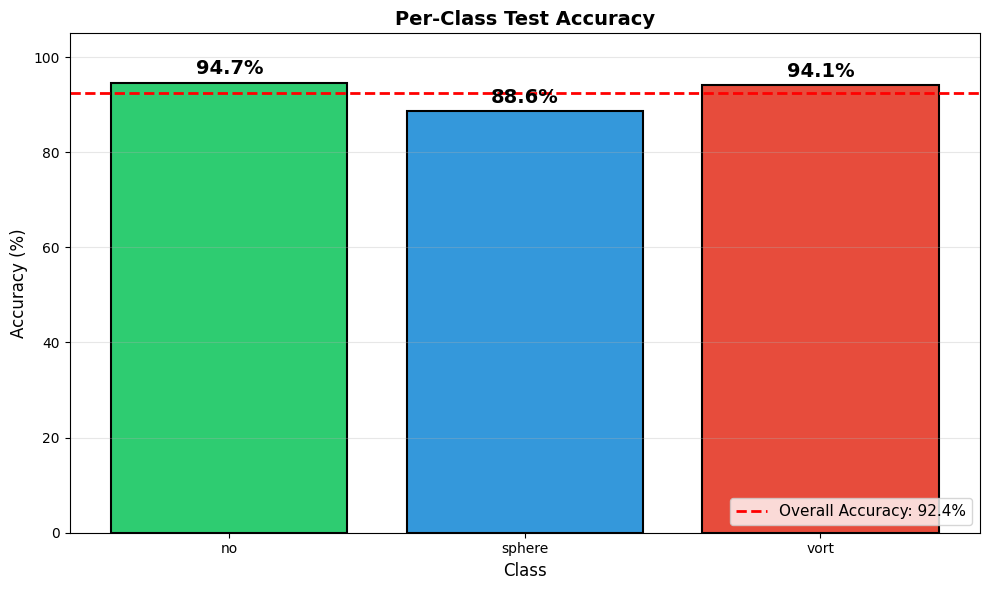

In [24]:
per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2ecc71', '#3498db', '#e74c3c']
bars = ax.bar(class_names, per_class_acc, color=colors, edgecolor='black', linewidth=1.5)

for bar, acc in zip(bars, per_class_acc):
    height = bar.get_height()
    ax.annotate(f'{acc:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=14, fontweight='bold')

ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_xlabel('Class', fontsize=12)
ax.set_title('Per-Class Test Accuracy', fontsize=14, fontweight='bold')
ax.set_ylim(0, 105)
ax.axhline(y=test_acc*100, color='red', linestyle='--',
           label=f'Overall Accuracy: {test_acc*100:.1f}%', linewidth=2)
ax.legend(loc='lower right', fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


In [26]:
model_save_path = "hybrid_qcnn_resnet18_v10_torchquantum.pth"
torch.save({
    'model_state_dict': model_hybrid.state_dict(),
    'optimizer_state_dict': optimizer_hybrid.state_dict(),
    'history': history,
    'config': {
        'n_qubits': n_qubits,
        'q_depth': q_depth,
        'unfreeze_layers': UNFREEZE_LAYERS,
        'dropout_rate': DROPOUT_RATE,
        'hidden_dim': HIDDEN_DIM,
        'num_classes': num_classes,
        'class_names': class_names,
        'quantum_backend': 'torchquantum',
    },
    'test_accuracy': test_acc,
    'test_roc_auc': test_roc_auc,
}, model_save_path)
print(f"Model saved to: {model_save_path}")


Model saved to: hybrid_qcnn_resnet18_v10_torchquantum.pth


In [27]:
print(" " + "="*70)
print("     QUANTUM TRANSFER LEARNING v5 - FINAL SUMMARY")
print("="*70)

print(f"Architecture:")
print(f"  Classical Backbone: ResNet18 (ImageNet pretrained)")
print(f"  Fine-tuned Layers: {UNFREEZE_LAYERS}")
print(f"  Quantum Circuit: {n_qubits} qubits, {q_depth} layers")
print(f"  Rotations: RY + RZ + RX (all three axes)")
print(f"  Entanglement: Forward + Reverse + Skip + Circular")
print(f"  Pre-net: 512 -> 256 -> {HIDDEN_DIM} -> {n_qubits}")
print(f"  Post-net: {n_qubits} -> 32 -> 16 -> {num_classes}")

print(f"Training Settings:")
print(f"  Learning rate: {step}")
print(f"  ResNet LR factor: {resnet_lr_factor}")
print(f"  Batch size: {batch_size}")
print(f"  Weight decay: {weight_decay}")
print(f"  Warmup epochs: {WARMUP_EPOCHS}")

print(f"Performance:")
print(f"  Best Validation Accuracy: {max(history['val_acc'])*100:.2f}%")
print(f"  Test Accuracy: {test_acc*100:.2f}%")
print(f"  Test ROC-AUC: {test_roc_auc:.4f}")

print(f"Per-Class Test Accuracy:")
for i, cls in enumerate(class_names):
    print(f"  {cls}: {per_class_acc[i]:.2f}%")

print(f"Total Training Time: {(time.time() - start_time)/60:.1f} minutes")
print(" " + "="*70)
print("                     EVALUATION COMPLETE")
print("="*70)


     QUANTUM TRANSFER LEARNING v5 - FINAL SUMMARY
Architecture:
  Classical Backbone: ResNet18 (ImageNet pretrained)
  Fine-tuned Layers: ['layer1', 'layer2', 'layer3', 'layer4']
  Quantum Circuit: 8 qubits, 6 layers
  Rotations: RY + RZ + RX (all three axes)
  Entanglement: Forward + Reverse + Skip + Circular
  Pre-net: 512 -> 256 -> 128 -> 8
  Post-net: 8 -> 32 -> 16 -> 3
Training Settings:
  Learning rate: 0.001
  ResNet LR factor: 0.1
  Batch size: 64
  Weight decay: 0.0001
  Warmup epochs: 5
Performance:
  Best Validation Accuracy: 92.65%
  Test Accuracy: 92.40%
  Test ROC-AUC: 0.9837
Per-Class Test Accuracy:
  no: 94.65%
  sphere: 88.58%
  vort: 94.07%
Total Training Time: 169.7 minutes
                     EVALUATION COMPLETE
